In [2]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
from sklearn.model_selection import train_test_split

data = fetch_california_housing()

# pretvaranje u DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# dodavanje ciljne varijable
df['MedHouseValue'] = data.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MedInc         20640 non-null  float64
 1   HouseAge       20640 non-null  float64
 2   AveRooms       20640 non-null  float64
 3   AveBedrms      20640 non-null  float64
 4   Population     20640 non-null  float64
 5   AveOccup       20640 non-null  float64
 6   Latitude       20640 non-null  float64
 7   Longitude      20640 non-null  float64
 8   MedHouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Skup podataka sadrži informacije o nekretninama u Kaliforniji

Ulazne varijable uključuju:
    MedInc (prosječni prihod), HouseAge (starost kuće), AveRooms, AveBedrms itd.
Ciljna varijabla je MedHouseValue (srednja vrijednost kuće)

In [5]:
X = df.drop('MedHouseValue', axis=1)
y = df['MedHouseValue']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

Podaci su podijeljeni na:
    80% za treniranje i 20% za testiranje
random_state=42 osigurava da svaki put dobijemo iste rezultate

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Skaliranje pretvara podatke tako da imaju srednju vrijednost 0 i standardnu devijaciju 1
Neuronske mreže bolje uče kada su ulazne varijable na istoj skali
Bez skaliranja model može sporije učiti ili dati lošije rezultate

In [8]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),  
    activation='relu',
    solver='adam',
    max_iter=200,
    random_state=42
)

# treniranje
mlp.fit(X_train_scaled, y_train)

# predikcije
y_pred_mlp = mlp.predict(X_test_scaled)

Model koristi neuronsku mrežu s dva skrivena sloja (64 i 32 neurona)
Aktivacijska funkcija je ReLU
Optimizator je Adam
Model uči iz trenirajućih podataka i predviđa vrijednosti na testnom skupu

In [9]:
rezultati = pd.DataFrame({
    "Stvarna vrijednost": y_test.values[:10],
    "Predviđena vrijednost": y_pred_mlp[:10]
})

print(rezultati)

   Stvarna vrijednost  Predviđena vrijednost
0             0.47700               0.458882
1             0.45800               0.943019
2             5.00001               4.885054
3             2.18600               2.548500
4             2.78000               2.691081
5             1.58700               1.422635
6             1.98200               2.230516
7             1.57500               1.528058
8             3.40000               2.719497
9             4.46600               4.687796


Iz prikazanih rezultata može se vidjeti da model relativno dobro prati stvarne vrijednosti
Predviđene vrijednosti su bliske stvarnima, iako postoje manja odstupanja u pojedinim slučajevima

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()
model.add(Input(shape=(X_train_scaled.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

Model je napravljen kao neuronska mreža s dva skrivena sloja (64 i 32 neurona).
Koristi se ReLU aktivacijska funkcija, a izlazni sloj nema aktivaciju jer se radi o regresiji (predviđanje brojeva).

In [11]:
model.compile(
    optimizer='adam',
    loss='mse'
)

history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.1322 - val_loss: 0.4795
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4161 - val_loss: 0.4186
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3800 - val_loss: 0.4168
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4019 - val_loss: 0.3838
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3550 - val_loss: 0.3962
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3347 - val_loss: 0.3614
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3329 - val_loss: 0.3550
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3185 - val_loss: 0.3434
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3221 - val_loss: 0.3342
Epoch 10/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3230 - val_loss: 0.4015
Epoch 11/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4176 - val_loss: 0.3328
Epoch 12/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# MLP
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)

# Keras
y_pred_keras = model.predict(X_test_scaled).flatten()

rmse_keras = np.sqrt(mean_squared_error(y_test, y_pred_keras))
mae_keras = mean_absolute_error(y_test, y_pred_keras)
r2_keras = r2_score(y_test, y_pred_keras)

print("MLP:", rmse_mlp, mae_mlp, r2_mlp)
print("Keras:", rmse_keras, mae_keras, r2_keras)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 915us/step
MLP: 0.5237259966403428 0.3505032325708228 0.7906844930770183
Keras: 0.5767976973186025 0.38538128700053736 0.7461131683646928


MLP model ima bolju točnost od Keras modela jer ima manju grešku (RMSE i MAE) i veći R²,to znači da MLP bolje predviđa cijene kuća na ovom skupu podataka.
Oba modela daju dobre rezultate, ali MLP je u ovom slučaju precizniji.

In [15]:
rezultati = pd.DataFrame({
    "Model": ["MLP", "Keras"],
    "RMSE": [rmse_mlp, rmse_keras],
    "MAE": [mae_mlp, mae_keras],
    "R2": [r2_mlp, r2_keras]
})

# zaokruživanje
rezultati = rezultati.round(3)

rezultati

,Model,RMSE,MAE,R2
0,MLP,0.524,0.351,0.791
1,Keras,0.577,0.385,0.746


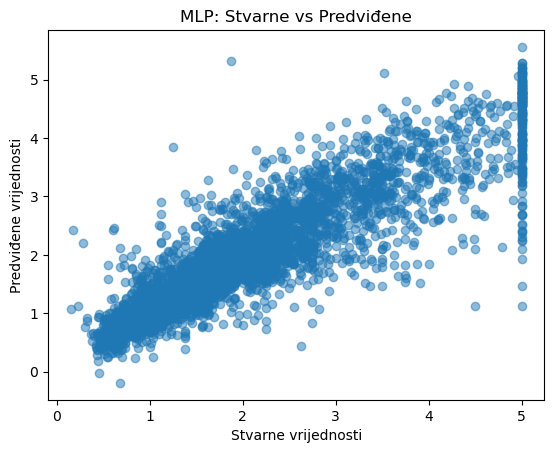

In [17]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_mlp, alpha=0.5)
plt.xlabel("Stvarne vrijednosti")
plt.ylabel("Predviđene vrijednosti")
plt.title("MLP: Stvarne vs Predviđene")
plt.show()

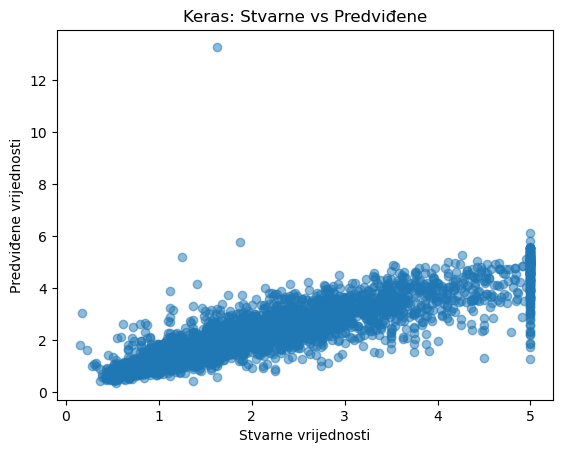

In [18]:
plt.scatter(y_test, y_pred_keras, alpha=0.5)
plt.xlabel("Stvarne vrijednosti")
plt.ylabel("Predviđene vrijednosti")
plt.title("Keras: Stvarne vs Predviđene")
plt.show()

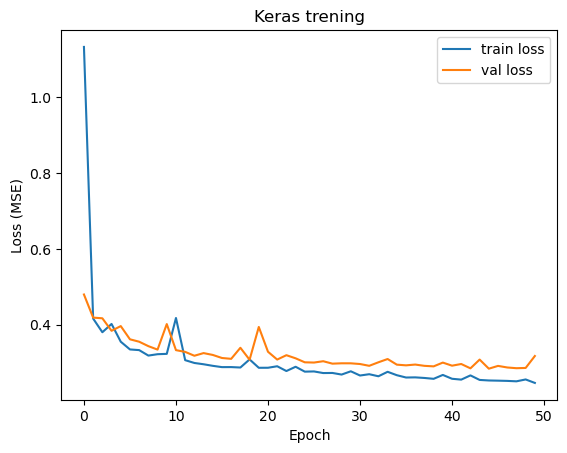

In [19]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Keras trening")
plt.legend()
plt.show()

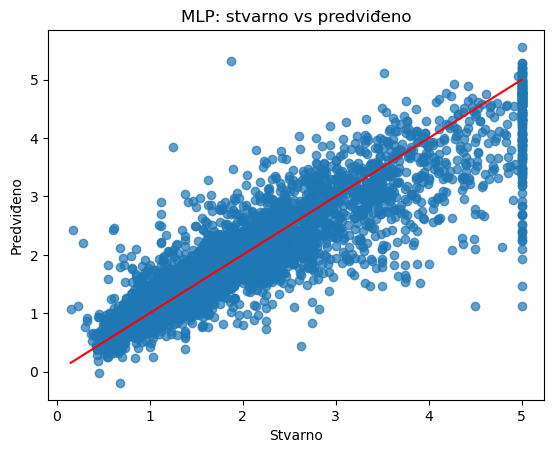

In [25]:
plt.scatter(y_test, y_pred_mlp, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.title("MLP: stvarno vs predviđeno")
plt.xlabel("Stvarno")
plt.ylabel("Predviđeno")
plt.show()